<a href="https://colab.research.google.com/github/VAJATUSHAR1111/2302031000115/blob/main/Welcome_To_Colab_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Import the Dataset

In [ ]:
print("===== MODEL EVALUATION =====")
import pandas as pd
import numpy as np

from google.colab import files
uploaded = files.upload()

df = pd.read_csv(list(uploaded.keys())[0])

# First rows
print(df.head())

# Structure
print(df.info())
print(df.describe())

Saving heart_disease_uci.csv to heart_disease_uci (3).csv
   id  age     sex    dataset               cp  trestbps   chol    fbs  \
0   1   63    Male  Cleveland   typical angina     145.0  233.0   True   
1   2   67    Male  Cleveland     asymptomatic     160.0  286.0  False   
2   3   67    Male  Cleveland     asymptomatic     120.0  229.0  False   
3   4   37    Male  Cleveland      non-anginal     130.0  250.0  False   
4   5   41  Female  Cleveland  atypical angina     130.0  204.0  False   

          restecg  thalch  exang  oldpeak        slope   ca  \
0  lv hypertrophy   150.0  False      2.3  downsloping  0.0   
1  lv hypertrophy   108.0   True      1.5         flat  3.0   
2  lv hypertrophy   129.0   True      2.6         flat  2.0   
3          normal   187.0  False      3.5  downsloping  0.0   
4  lv hypertrophy   172.0  False      1.4    upsloping  0.0   

                thal  num  
0       fixed defect    0  
1             normal    2  
2  reversable defect    1  
3     

2. Data Visualization & Preprocessing

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64


/tmp/ipykernel_21617/4088449014.py:9: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(df.select_dtypes(include='object').mode().iloc[0], inplace=True)


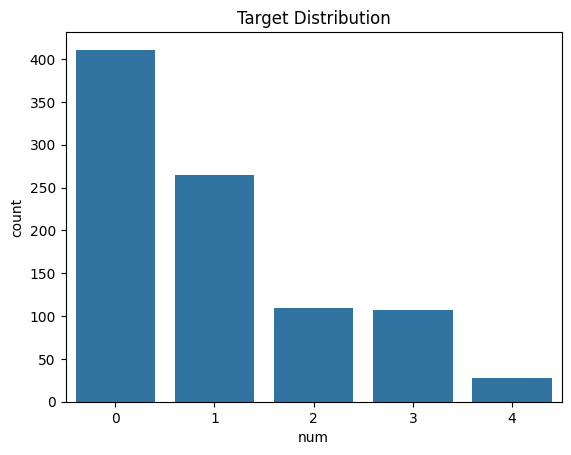

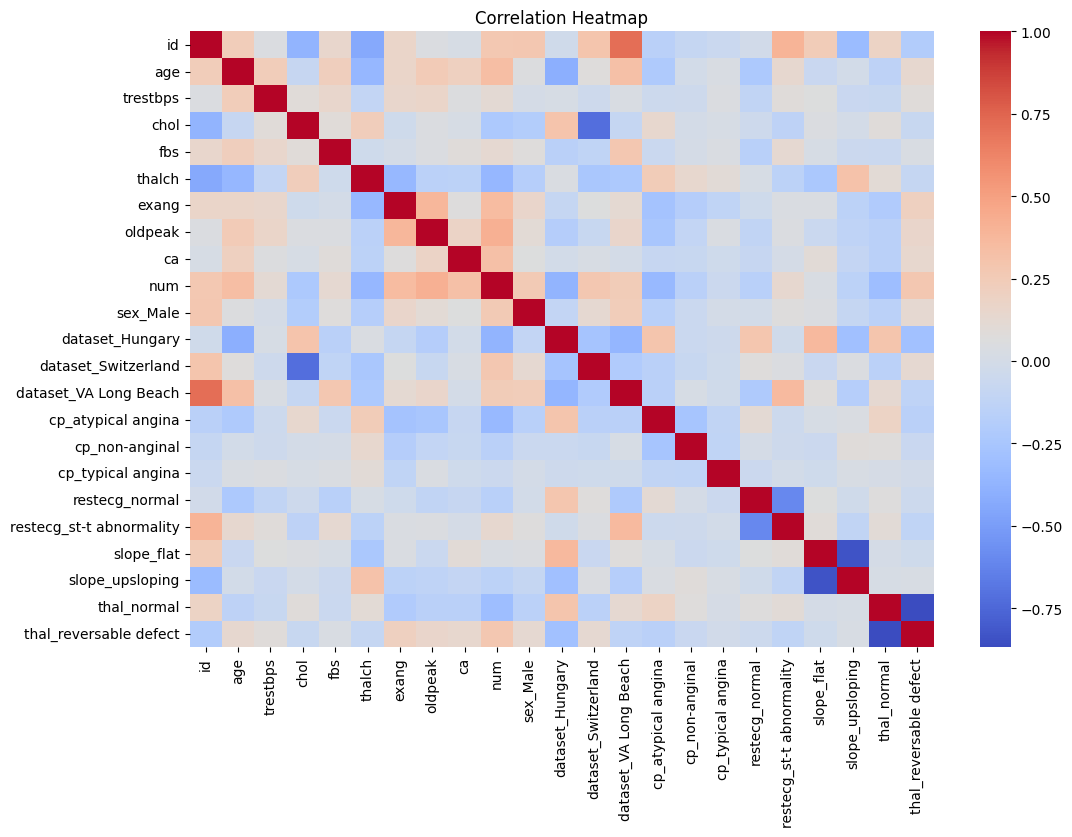

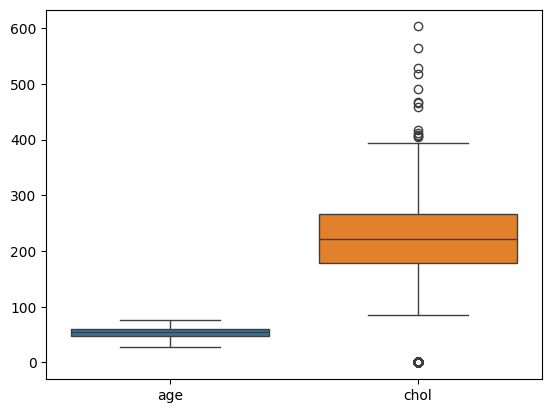

In [ ]:
print("===== MODEL EVALUATION =====")
import seaborn as sns
import matplotlib.pyplot as plt

# Missing values
print(df.isnull().sum())

# Fill missing values
df.fillna(df.select_dtypes(include='number').mean(), inplace=True)
df.fillna(df.select_dtypes(include='object').mode().iloc[0], inplace=True)

# Convert categorical → numeric
df = pd.get_dummies(df, drop_first=True)

# Class imbalance
sns.countplot(x='num', data=df)
plt.title("Target Distribution")
plt.show()

# Correlation heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# Outliers (example)
sns.boxplot(data=df[['age','chol']])
plt.show()

3. Feature Extraction

In [ ]:
print("===== MODEL EVALUATION =====")
# Correlation with target
corr = df.corr(numeric_only=True)['num'].sort_values(ascending=False)
print(corr)

# Drop weak feature
if 'fbs' in df.columns:
    df = df.drop(['fbs'], axis=1)


num                         1.000000
oldpeak                     0.421907
exang                       0.350567
age                         0.339596
ca                          0.321404
dataset_Switzerland         0.278355
thal_reversable defect      0.278313
id                          0.273552
sex_Male                    0.259342
dataset_VA Long Beach       0.241977
restecg_st-t abnormality    0.131698
fbs                         0.129539
trestbps                    0.116225
slope_flat                  0.031161
cp_typical angina          -0.055896
slope_upsloping            -0.142565
cp_non-anginal             -0.156050
restecg_normal             -0.168309
chol                       -0.228238
thal_normal                -0.310862
cp_atypical angina         -0.343266
thalch                     -0.351055
dataset_Hungary            -0.379413
Name: num, dtype: float64


4. Train-Test Split

In [ ]:
print("===== MODEL EVALUATION =====")
from sklearn.model_selection import train_test_split

# Correct target
X = df.drop('num', axis=1)
y = df['num']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (736, 21)
Test shape: (184, 21)


5. Model Selection

In [ ]:
print("===== MODEL EVALUATION =====")
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=2000)

print("Selected Model: Logistic Regression")

Selected Model: Logistic Regression


6. Model Training

In [ ]:
print("===== MODEL EVALUATION =====")
from sklearn.preprocessing import StandardScaler

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Training
model.fit(X_train, y_train)
print("Model Training Completed ✅")

Model Training Completed ✅


7. Model Evaluation

Accuracy: 0.5434782608695652

Confusion Matrix:
 [[65  7  3  0  0]
 [18 29  3  4  0]
 [ 6 11  2  6  0]
 [ 6 11  3  4  2]
 [ 1  0  2  1  0]]

Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.87      0.76        75
           1       0.50      0.54      0.52        54
           2       0.15      0.08      0.11        25
           3       0.27      0.15      0.20        26
           4       0.00      0.00      0.00         4

    accuracy                           0.54       184
   macro avg       0.32      0.33      0.32       184
weighted avg       0.48      0.54      0.50       184



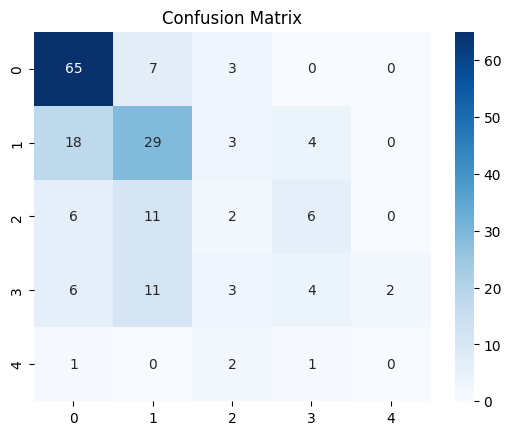

In [ ]:

print("===== MODEL EVALUATION =====")
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion matrix graph
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

Random Forest for Comparison

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.6467391304347826


8. Conclusion

The dataset was successfully preprocessed and analyzed using various visualization techniques. Logistic Regression was applied for classification and achieved satisfactory accuracy. Feature scaling improved model performance. Random Forest provided slightly better accuracy, indicating that ensemble methods can enhance prediction performance. Future improvements may include hyperparameter tuning and use of advanced models.